In [5]:
cd Escritorio/SERRATIA/Model/

/home/marcos/Escritorio/SERRATIA/Model


# Top Down Reconstruction Metabolic Model - Serratia liquefaciens Strain UNJFSC 002

In [6]:
import escher # for visualization
from escher import Builder
import cobra # for model simulations
from time import sleep
escher.rc['never_ask_before_quit'] = True

In [7]:
!wget -nc http://bigg.ucsd.edu/static/models/iJO1366.json

model = cobra.io.load_json_model('iJO1366.json')

El fichero ‘iJO1366.json’ ya está ahí, no se recupera.



# Inspeccionar las Propiedades del Modelo Metabolico - GEMs

In [8]:
num_reactions = len(model.reactions)
num_metabolites = len(model.metabolites)
num_genes = len(model.genes)

print("Model information")
print("Model ID is: {}".format(model.id))
print("Number of reactions: {}".format(num_reactions))
print("Number of metabolites: {}".format(num_metabolites))
print("Number of genes: {}".format(num_genes))
print("Model compartments:")
for k, v in model.compartments.items():
    print(k + '\t' + v)
print("Model objective is:")
print(model.objective)

Model information
Model ID is: iJO1366
Number of reactions: 2583
Number of metabolites: 1805
Number of genes: 1367
Model compartments:
c	cytosol
e	extracellular space
p	periplasm
Model objective is:
Maximize
1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1


In [9]:
## Funciones del Modelo
print(model.summary) #(float_format = None, names = True)) #mmol/gDW/h

<bound method Model.summary of <Model iJO1366 at 0x7a6131a13490>>


In [10]:
# Biomasa del Modelo - Metabolitos - Rx - Flux - Rangos - C-number - C-Flux
model.summary(fva=0.95) #, float_format = None, names = True)

Metabolite,Reaction,Flux,Range,C-Number,C-Flux
ca2_e,EX_ca2_e,0.005113,[0.004858; 0.005113],0,0.00%
cl_e,EX_cl_e,0.005113,[0.004858; 0.005113],0,0.00%
cobalt2_e,EX_cobalt2_e,2.456E-05,[2.333E-05; 2.456E-05],0,0.00%
cu2_e,EX_cu2_e,0.0006965,[0.0006617; 0.0006965],0,0.00%
fe2_e,EX_fe2_e,0.01578,[-4.978; 1000],0,0.00%
glc__D_e,EX_glc__D_e,10,[9.507; 10],6,100.00%
k_e,EX_k_e,0.1918,[0.1822; 0.1918],0,0.00%
mg2_e,EX_mg2_e,0.008522,[0.008096; 0.008522],0,0.00%
mn2_e,EX_mn2_e,0.0006788,[0.0006449; 0.0006788],0,0.00%
mobd_e,EX_mobd_e,0.0001267,[0.0001204; 0.0001271],0,0.00%


### Reacciones del Modelo Metabolico de iJO1366 para Serratia liquefaciens Strain UNJFSC 002 - (Nitrogeno - Fosfato - GABA - IAA)

In [11]:
def buscar_reacciones(modelo, palabra_clave):
    resultados = []
    for rxn in modelo.reactions:
        if palabra_clave.lower() in rxn.name.lower() or palabra_clave.lower() in rxn.id.lower():
            resultados.append((rxn.id, rxn.name))
    return resultados

In [12]:
import pandas as pd

In [13]:
reacciones_nitrogeno = []
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    reacciones_nitrogeno += buscar_reacciones(model, keyword)
reacciones_nitrogeno = list(set(reacciones_nitrogeno))
df_nitrogeno = pd.DataFrame(reacciones_nitrogeno, columns=["reaction_id", "reaction_name"])
df_nitrogeno.to_csv("reacciones_nitrogeno.csv", index=False)
print(df_nitrogeno.head())

   reaction_id                                      reaction_name
0      NO3R1pp        Nitrate reductase (Ubiquinol-8) (periplasm)
1     GLNabcpp   L-glutamine transport via ABC system (periplasm)
2  GLUABUTt7pp     4-aminobutyrate/glutamate antiport (periplasm)
3    EX_urea_e                                      Urea exchange
4       UAMAGS  UDP-N-acetylmuramoyl-L-alanyl-D-glutamate synt...


In [14]:
reacciones_fosfato = []
for keyword in ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']:
    reacciones_fosfato += buscar_reacciones(model, keyword)
# Eliminar duplicados
reacciones_fosfato = list(set(reacciones_fosfato))
# Convertir a DataFrame
df_fosfato = pd.DataFrame(reacciones_fosfato, columns=["reaction_id", "reaction_name"])
# Guardar como CSV
df_fosfato.to_csv("reacciones_fosfato.csv", index=False)
# Mostrar ejemplo
print(df_fosfato.head())

  reaction_id                                      reaction_name
0    MECDPDH5  2C-methyl-D-erythritol 2,4 cyclodiphosphate de...
1  APG3PAT120  Acyl-phosphate:glycerol-3-phosphate acyltransf...
2        NTP1                    Nucleoside-triphosphatase (ATP)
3       RBP4E                   L-ribulose-phosphate 4-epimerase
4       MEPCT  2-C-methyl-D-erythritol 4-phosphate cytidylylt...


In [15]:
reacciones_gaba = buscar_reacciones(model, 'GABA')
df_gaba = pd.DataFrame(reacciones_gaba, columns=["reaction_id", "reaction_name"])
df_gaba.to_csv("reacciones_gaba.csv", index=False)
print(df_gaba.head())

  reaction_id                                      reaction_name
0    GGGABADr  Gamma-glutamyl-gamma aminobutyric acid dehydro...
1     GGGABAH   Gamma-glutamyl-gamma-aminobutyric acid hydrolase


In [16]:
reacciones_iaa = []
for keyword in ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']:
    reacciones_iaa += buscar_reacciones(model, keyword)
reacciones_iaa = list(set(reacciones_iaa))
df_iaa = pd.DataFrame(reacciones_iaa, columns=["reaction_id", "reaction_name"])
df_iaa.to_csv("reacciones_iaa.csv", index=False)
print(df_iaa.head())

   reaction_id                                      reaction_name
0        TRPS2                       Tryptophan synthase (indole)
1  EX_trp__L_e                              L-Tryptophan exchange
2         IGPS               Indole-3-glycerol-phosphate synthase
3       TRPtex  L-tryptophan transport via diffusion (extracel...
4  EX_indole_e                                    Indole exchange


In [17]:
ls

e_coli_Central_map.html               mi_mapitaa_Nitrogen_0001.html
E_coli_Draft_Central_map001.html      mi_mapitaa_Nitrogen_gocito.html
E_coli_Draft_Central_map01.html       mi_mapitaa_Nitrogen.html
E_coli_Draft_Central_map_gocito.html  Model-iJO1366-UNJFSC002-.ipynb
E_coli_Draft_Central_map.html         Nitrogen_Fixation
fosfato_map.html                      Nitrogen_Fixation_GAAA.html
iJO1366.json                          nitrogen_map_focus.html
mapa_ciclo_IAA.html                   nitrogen_only_map_GAAAAAAA.html
mapa_gaba.html                        nitrogen_only_map_ga.html
mi_mapitaa01.html                     reacciones_fosfato.csv
mi_mapitaaaaaa_05.html                reacciones_gaba.csv
mi_mapitaaaaa_ga.html                 reacciones_iaa.csv
mi_mapitaa_fixation_Nitrogen.html     reacciones_nitrogeno.csv
mi_mapitaa_gacito.html                ruta_nitrogeno_fosfato.html
mi_mapitaa.html


## Creacion del Modelo Metabolico iJO1366

In [18]:
from escher import Builder
import json
import requests

In [19]:
escher.list_available_maps()

[{'organism': 'Saccharomyces cerevisiae',
  'map_name': 'iMM904.Central carbon metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Inositol retinol metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Glycolysis TCA PPP'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Tryptophan metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Carbohydrate metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Amino acid metabolism (partial)'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Nucleotide metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid biosynthesis (saturated)'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Nucleotide and histidine biosynthesis'},
 {'organism': 'Escherichia coli', 'map_name': 'e_coli_core.Core metabolism'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Central metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid beta-oxidation'}

In [20]:
escher.list_available_models()

[{'organism': 'Saccharomyces cerevisiae', 'model_name': 'iMM904'},
 {'organism': 'Homo sapiens', 'model_name': 'RECON1'},
 {'organism': 'Escherichia coli', 'model_name': 'e_coli_core'},
 {'organism': 'Escherichia coli', 'model_name': 'iJO1366'}]

In [21]:
builder = Builder(
    map_name='iJO1366.Central metabolism',
    model_name='iJO1366'
)

In [22]:
builder = Builder(
    height=600,
    map_name=None,
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/models/Escherichia%20coli/iJO1366.json',
)
builder

Builder(height=600, never_ask_before_quit=True)

In [23]:
builder = Builder(
    height=600,
    map_name=None,
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
)
builder.save_html('mi_mapitaa_gacito.html')

In [24]:
timestep = 0.1
duration = 90 # seconds
min_flux = 0 # minimum flux value
max_flux = 50 # maximum flux value
step = 1 # increment in flux value
val = min_flux
with model:
    for _ in range(int(duration / timestep)):
        model.reactions.EX_o2_e.lower_bound = -val # exchange flux variation
        solution = model.optimize() # solve model
        builder.reaction_data = solution.fluxes # add fluxes to model
        if val <= max_flux:
            val += step # increment step
        else:
            val = min_flux # reset
        sleep(timestep)

In [25]:
builder.save_html('E_coli_Draft_Central_map_gocito1.html')

In [26]:
escher.list_available_maps()

[{'organism': 'Saccharomyces cerevisiae',
  'map_name': 'iMM904.Central carbon metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Inositol retinol metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Glycolysis TCA PPP'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Tryptophan metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Carbohydrate metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Amino acid metabolism (partial)'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Nucleotide metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid biosynthesis (saturated)'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Nucleotide and histidine biosynthesis'},
 {'organism': 'Escherichia coli', 'map_name': 'e_coli_core.Core metabolism'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Central metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid beta-oxidation'}

## Ahora crearemos Modelos especificos para Ciclos de (N y P)

In [32]:
def buscar_reacciones(modelo, palabra):
    return [rxn.id for rxn in modelo.reactions if palabra.lower() in rxn.name.lower() or palabra.lower() in rxn.id.lower()]

# Palabras clave para buscar rutas
keywords_n = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
keywords_p = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']

# Buscar reacciones
reacciones_nitrogeno = []
reacciones_fosfato = []

for palabra in keywords_n:
    reacciones_nitrogeno += buscar_reacciones(model, palabra)

for palabra in keywords_p:
    reacciones_fosfato += buscar_reacciones(model, palabra)

# Eliminar duplicados
reacciones_nitrogeno = list(set(reacciones_nitrogeno))
reacciones_fosfato = list(set(reacciones_fosfato))

In [33]:
builder = Builder(
    model=model,
    reaction_ids=reacciones_nitrogeno + reacciones_fosfato,
    height=600
)
# Guardar como HTML
builder.save_html("ruta_nitrogeno_fosfato.html")

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


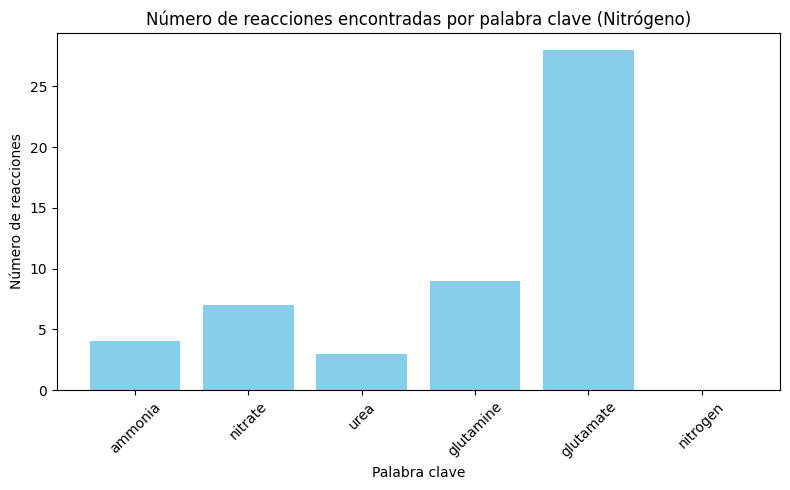

In [27]:
## Reaccion de Nitrogeno
import matplotlib.pyplot as plt

conteo_keywords = {}
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    matches = buscar_reacciones(model, keyword)
    conteo_keywords[keyword] = len(matches)

# Graficar
plt.figure(figsize=(8, 5))
plt.bar(conteo_keywords.keys(), conteo_keywords.values(), color='skyblue')
plt.title("Número de reacciones encontradas por palabra clave (Nitrógeno)")
plt.ylabel("Número de reacciones")
plt.xlabel("Palabra clave")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Ecuaciones Quimicas de las Reacciones de Nitrogeno
for rxn_id in df_nitrogeno["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"{rxn.id}: {rxn.reaction}")

NO3R1pp: 2.0 h_c + no3_c + q8h2_c --> h2o_c + 2.0 h_p + no2_c + q8_c
GLNabcpp: atp_c + gln__L_p + h2o_c --> adp_c + gln__L_c + h_c + pi_c
GLUABUTt7pp: 4abut_c + glu__L_p <=> 4abut_p + glu__L_c
EX_urea_e: urea_e --> 
UAMAGS: atp_c + glu__D_c + uama_c --> adp_c + h_c + pi_c + uamag_c
GLUPRT: gln__L_c + h2o_c + prpp_c --> glu__L_c + ppi_c + pram_c
NO3R1bpp: no3_p + q8h2_c --> h2o_p + no2_p + q8_c
CTPS2: atp_c + gln__L_c + h2o_c + utp_c --> adp_c + ctp_c + glu__L_c + 2.0 h_c + pi_c
ALAGLUE: LalaDglu_c <=> LalaLglu_c
NH4tpp: nh4_p <=> nh4_c
GLU5K: atp_c + glu__L_c --> adp_c + glu5p_c
EX_LalaDglu_e: LalaDglu_e --> 
LALADGLUtex: LalaDglu_e <=> LalaDglu_p
NH4tex: nh4_e <=> nh4_p
ETHAAL: etha_c --> acald_c + nh4_c
GLUR: glu__D_c <=> glu__L_c
ACGK: acglu_c + atp_c --> acg5p_c + adp_c
SGDS: h2o_c + sucglu_c --> glu__L_c + succ_c
LALGP: LalaLglu_c + h2o_c --> ala__L_c + glu__L_c
NO3t7pp: no2_c + no3_p --> no2_p + no3_c
EX_nh4_e: nh4_e <=> 
GLNtex: gln__L_e <=> gln__L_p
GLUSy: akg_c + gln__L_c + h_

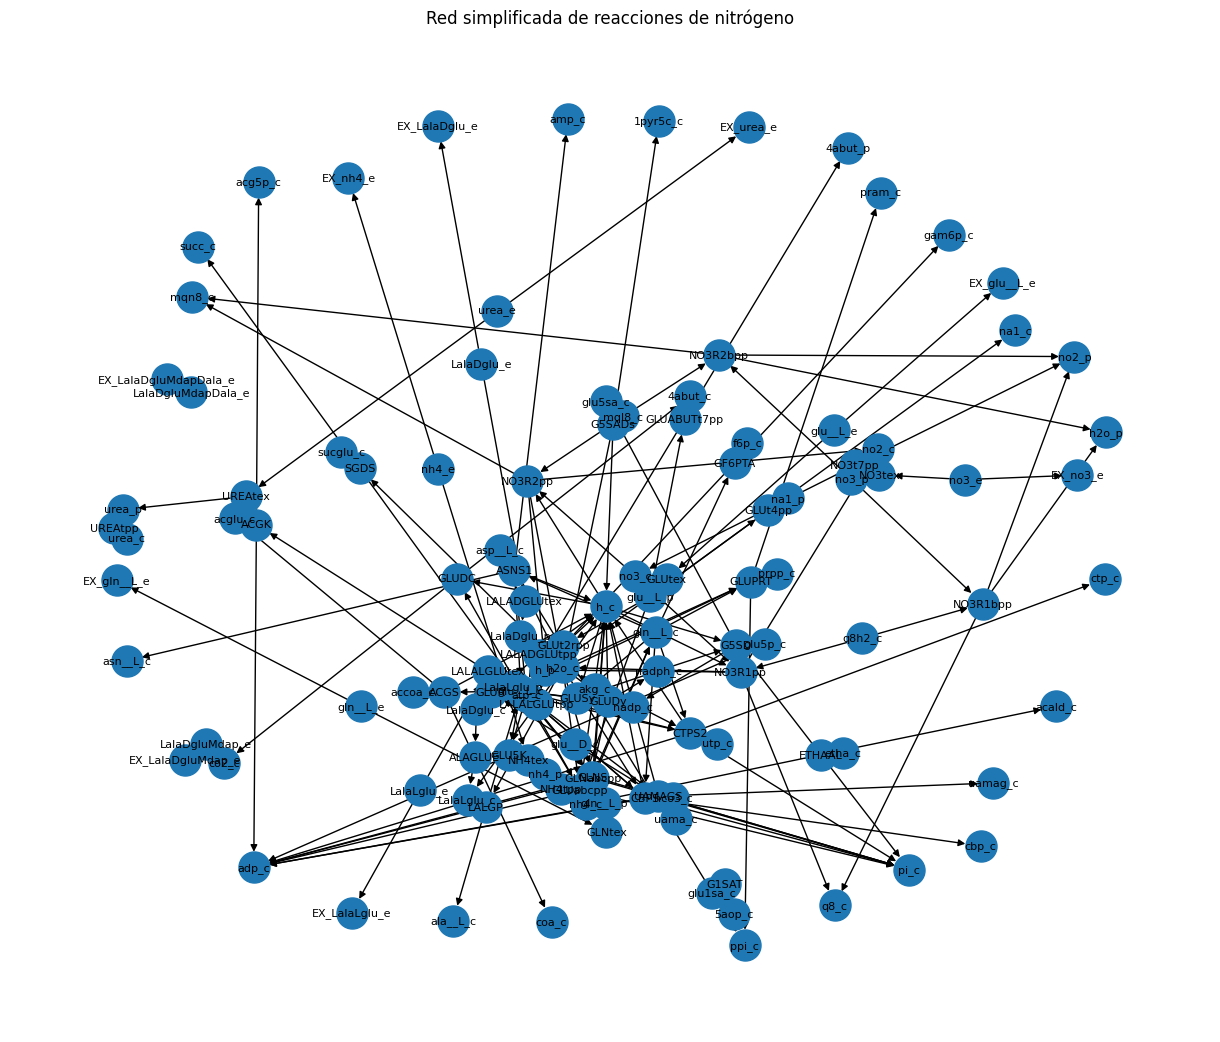

In [29]:
import networkx as nx

G = nx.DiGraph()
for rxn_id in df_nitrogeno["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

plt.figure(figsize=(12, 10))
nx.draw(G, with_labels=True, node_size=500, font_size=8)
plt.title("Red simplificada de reacciones de nitrógeno")
plt.show()

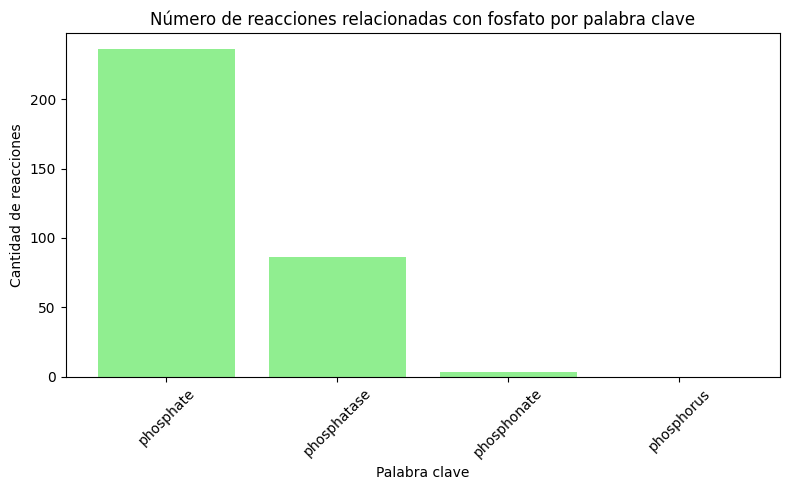

In [30]:
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_keywords_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

plt.figure(figsize=(8, 5))
plt.bar(conteo_keywords_fosfato.keys(), conteo_keywords_fosfato.values(), color='lightgreen')
plt.title("Número de reacciones relacionadas con fosfato por palabra clave")
plt.ylabel("Cantidad de reacciones")
plt.xlabel("Palabra clave")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#Ecuaciones de las Rx de Fosfato
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"{rxn.id}: {rxn.reaction}")

MECDPDH5: 2mecdp_c + 2.0 flxr_c + h_c --> 2.0 flxso_c + h2mb4p_c + h2o_c
APG3PAT120: ddcap_c + glyc3p_c --> 1ddecg3p_c + h_c + pi_c
NTP1: atp_c + h2o_c --> adp_c + h_c + pi_c
RBP4E: ru5p__L_c <=> xu5p__D_c
MEPCT: 2me4p_c + ctp_c + h_c --> 4c2me_c + ppi_c
IG3PS: gln__L_c + prlp_c --> aicar_c + eig3p_c + glu__L_c + h_c
FRUK: atp_c + f1p_c --> adp_c + fdp_c + h_c
RNDR1: adp_c + trdrd_c --> dadp_c + h2o_c + trdox_c
TGBPA: tagdp__D_c <=> dhap_c + g3p_c
ACPPAT160: h_c + palmACP_c + pi_c --> ACP_c + hdcap_c
GLYC2Ptex: glyc2p_e <=> glyc2p_p
COLIPAPabctex: atp_c + colipap_p + h2o_c --> adp_c + colipap_e + h_c + pi_c
AGPR: acg5sa_c + nadp_c + pi_c <=> acg5p_c + h_c + nadph_c
PGP120abcpp: atp_c + h2o_c + pgp120_c --> adp_c + h_c + pgp120_p + pi_c
RNDR4: trdrd_c + udp_c --> dudp_c + h2o_c + trdox_c
AGPAT181: 1odec11eg3p_c + octeACP_c --> ACP_c + pa181_c
KDOPS: ara5p_c + h2o_c + pep_c --> kdo8p_c + pi_c
TRE6PP: h2o_c + tre6p_c --> pi_c + tre_c
ACPPAT120: ddcaACP_c + h_c + pi_c --> ACP_c + ddcap_c
N

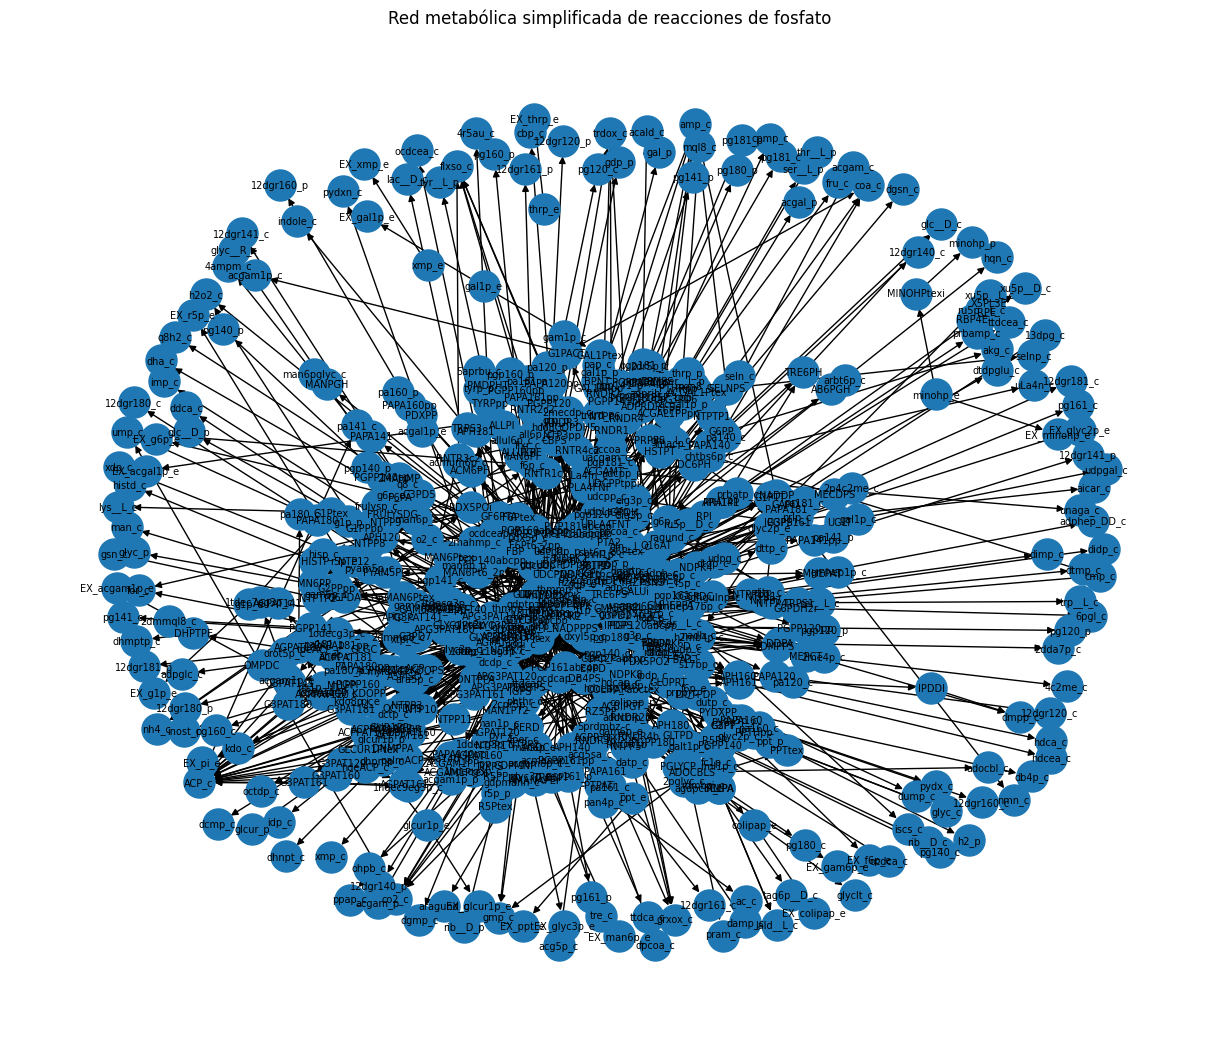

In [32]:
# Visualización de la Red de Fosfato
G = nx.DiGraph()
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

plt.figure(figsize=(12, 10))
nx.draw(G, with_labels=True, node_size=500, font_size=7)
plt.title("Red metabólica simplificada de reacciones de fosfato")
plt.show()

/tmp/ipykernel_35165/3023881873.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


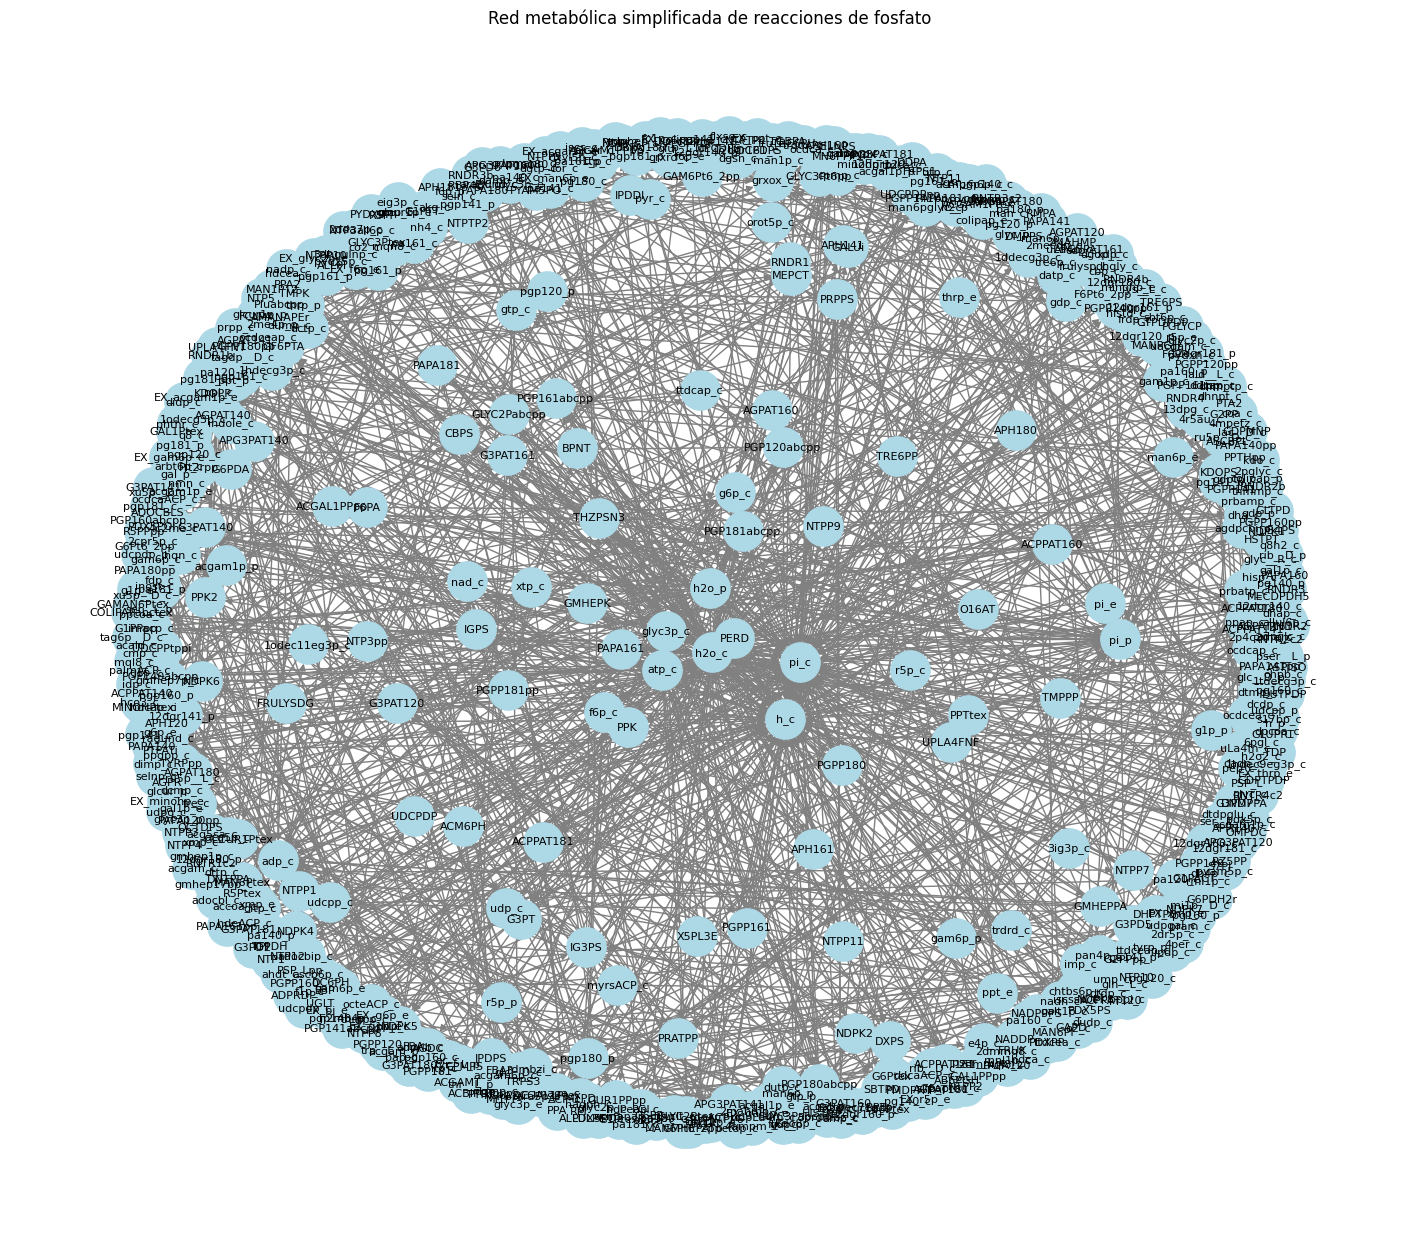

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

pos = nx.spring_layout(G, k=1.5, iterations=100)  # Aumentar k para más separación

# Dibujar la red
plt.figure(figsize=(14, 12))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="lightblue",
    edge_color="gray",
    font_size=8
)
plt.title("Red metabólica simplificada de reacciones de fosfato")
plt.tight_layout()
plt.show()

In [34]:
print(df_gaba.head())

  reaction_id                                      reaction_name
0    GGGABADr  Gamma-glutamyl-gamma aminobutyric acid dehydro...
1     GGGABAH   Gamma-glutamyl-gamma-aminobutyric acid hydrolase


/tmp/ipykernel_35165/3148437084.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


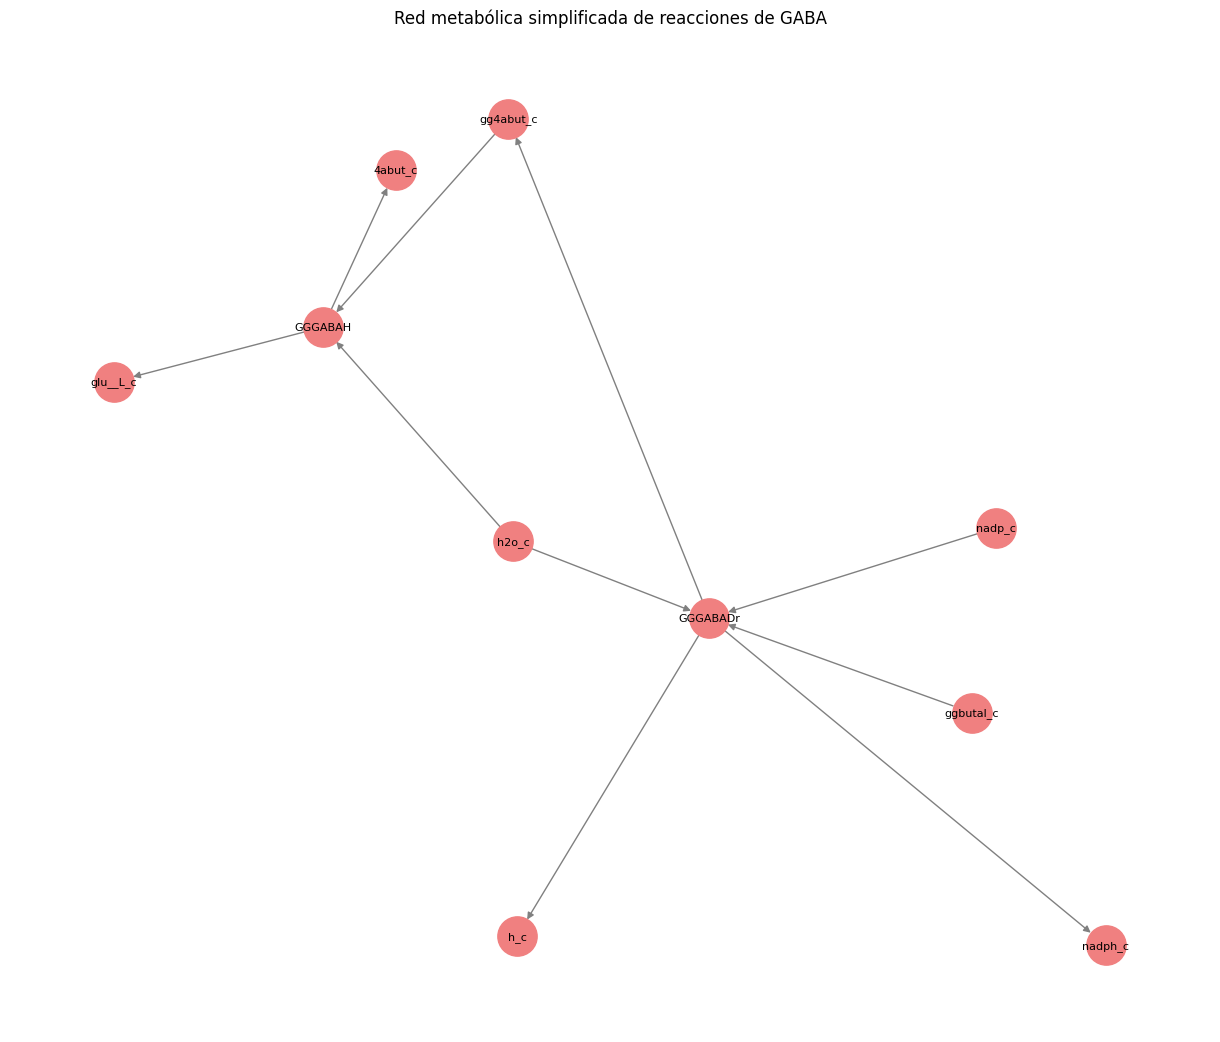

In [35]:
G = nx.DiGraph()
for rxn_id in df_gaba["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

pos = nx.spring_layout(G, k=1.5, iterations=100)

plt.figure(figsize=(12, 10))
nx.draw(G, pos,
        with_labels=True,
        node_size=800,
        node_color="lightcoral",
        edge_color="gray",
        font_size=8)
plt.title("Red metabólica simplificada de reacciones de GABA")
plt.tight_layout()
plt.show()

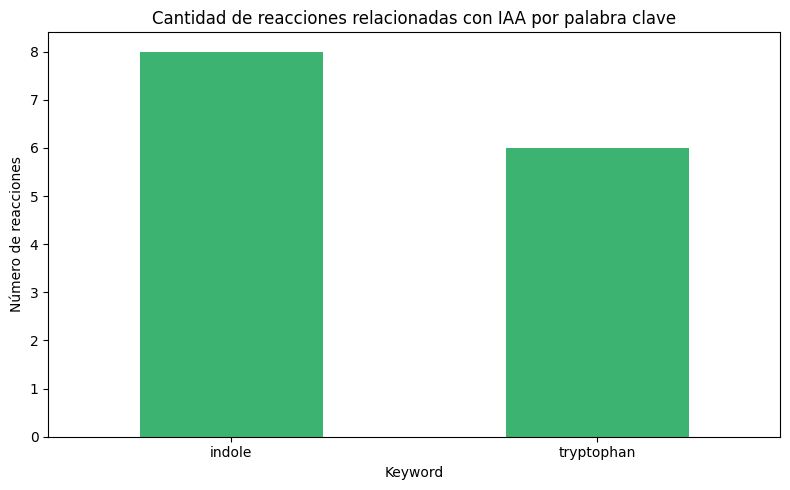

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

df_iaa_keywords = []
for keyword in ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']:
    for rxn in buscar_reacciones(model, keyword):
        df_iaa_keywords.append((rxn[0], rxn[1], keyword))

df_iaa_full = pd.DataFrame(df_iaa_keywords, columns=["reaction_id", "reaction_name", "keyword"])
df_iaa_full.drop_duplicates(subset=["reaction_id"], inplace=True)

plt.figure(figsize=(8, 5))
df_iaa_full['keyword'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title("Cantidad de reacciones relacionadas con IAA por palabra clave")
plt.xlabel("Keyword")
plt.ylabel("Número de reacciones")
plt.xticks(rotation=0)
plt.tight_layout()

/tmp/ipykernel_35165/3151292267.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


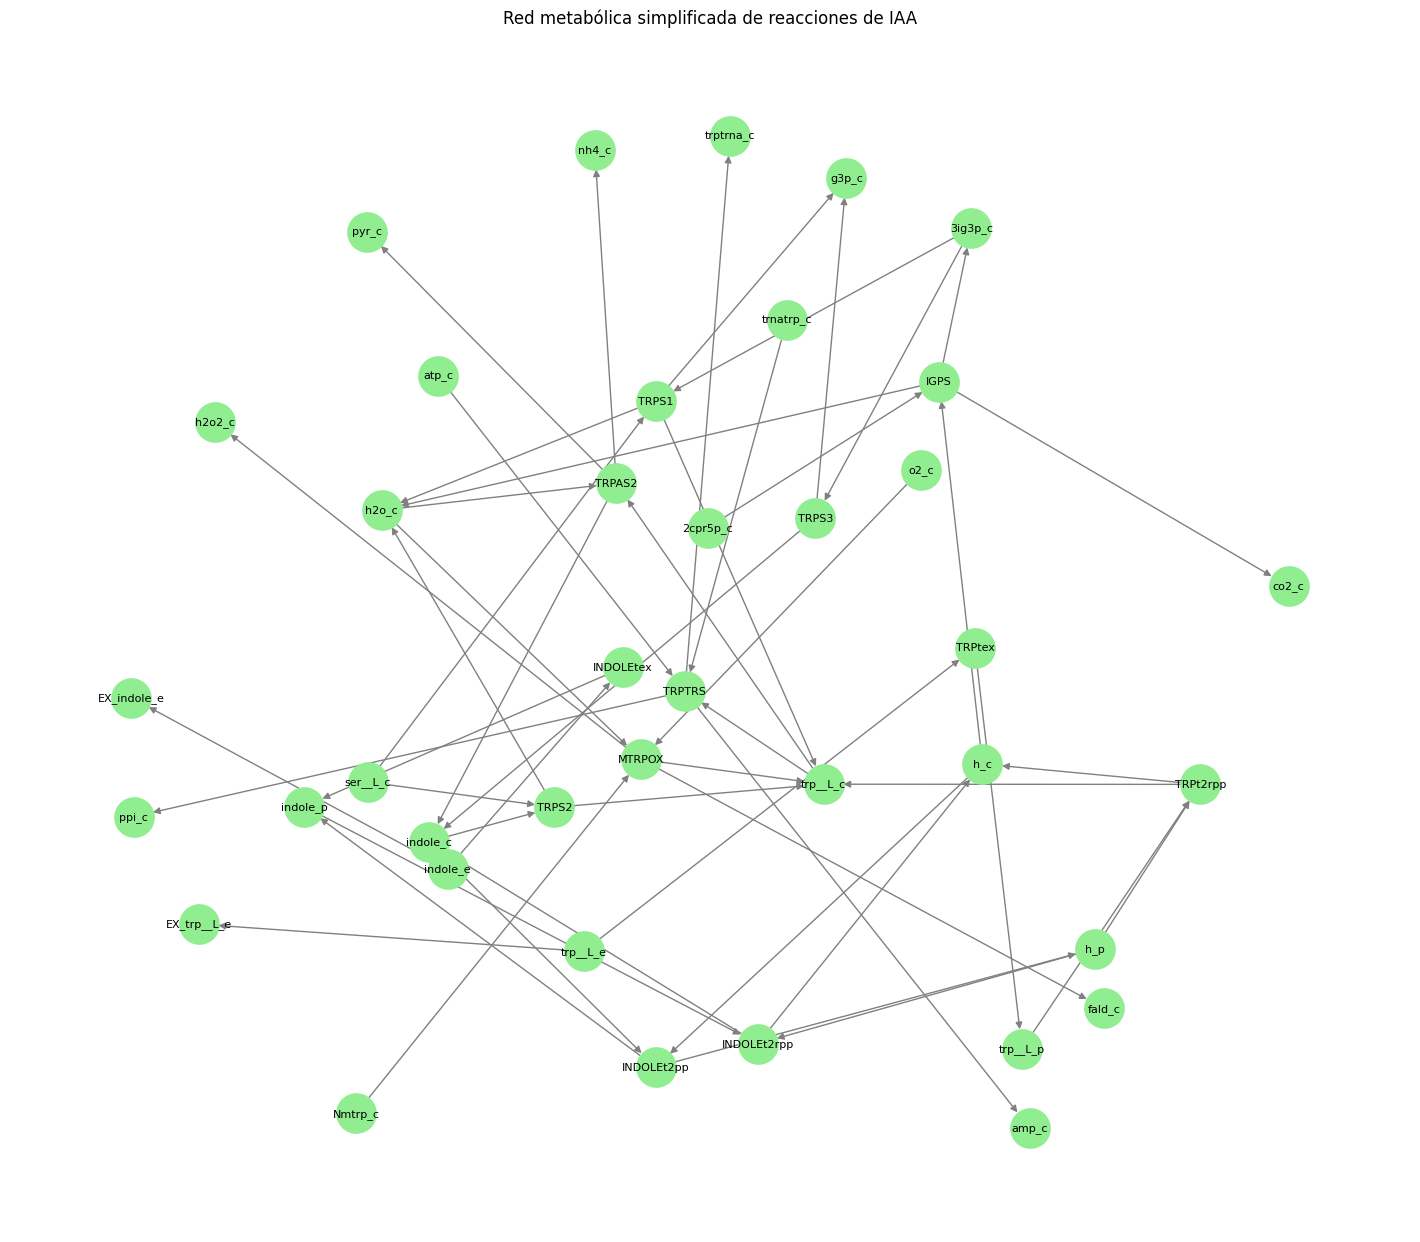

In [37]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for rxn_id in df_iaa["reaction_id"]:
    try:
        rxn = model.reactions.get_by_id(rxn_id)
        for met in rxn.reactants:
            G.add_edge(met.id, rxn.id)
        for met in rxn.products:
            G.add_edge(rxn.id, met.id)
    except KeyError:
        print(f"Reacción no encontrada en el modelo: {rxn_id}")

pos = nx.spring_layout(G, k=1.5, iterations=100)

plt.figure(figsize=(14, 12))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="lightgreen",
    edge_color="gray",
    font_size=8
)
plt.title("Red metabólica simplificada de reacciones de IAA")
plt.tight_layout()
plt.show()

In [38]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

model = load_model("iJO1366")

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions 
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

reacciones_nitrogeno = []
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    reacciones_nitrogeno += buscar_reacciones(model, keyword)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))

fluxes_nitrogeno = {rxn_id: 1.0 for rxn_id, rxn_name in reacciones_nitrogeno}

builder = Builder(
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json'
)

builder.reaction_data = fluxes_nitrogeno

builder.save_html('mi_mapitaaaaaa_0005.html')

In [39]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

builder = Builder(
    height=600,
    map_name=None,
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json'
)

reacciones_nitrogeno = []
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    reacciones_nitrogeno += buscar_reacciones(model, keyword)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))

fluxes_nitrogeno = {rxn_id: 1.0 for rxn_id, rxn_name in reacciones_nitrogeno}

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_nitrogeno
builder.save_html('mi_mapitaa_Nitrogen_gocito_01.html')

In [40]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

model = load_model("iJO1366") 

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions 
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

reacciones_nitrogeno = []
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    reacciones_nitrogeno += buscar_reacciones(model, keyword)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))

fluxes_nitrogeno = {rxn_id: 1.0 for rxn_id, rxn_name in reacciones_nitrogeno}

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_nitrogeno

builder.save_html('Nitrogen_Fixation_GAAA_01.html')

In [54]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

def buscar_reacciones(model, keyword):
    resultado = []
    for rxn in model.reactions:
        if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower():
            resultado.append((rxn.id, rxn.name))
    return resultado

model = load_model("iJO1366")  

reacciones_fosfato = []
for keyword in ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']:
    reacciones_fosfato += buscar_reacciones(model, keyword)

reacciones_fosfato = list(set(reacciones_fosfato))

fluxes_fosfato = {rxn_id: 1.0 for rxn_id, _ in reacciones_fosfato}

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_fosfato

builder.save_html('fosfato_map.html')

df_fosfato = pd.DataFrame(reacciones_fosfato, columns=["reaction_id", "reaction_name"])
df_fosfato.to_csv("reacciones_fosfato.csv", index=False)

print(df_fosfato.head())

    reaction_id                                      reaction_name
0   GAM6Pt6_2pp  D-Glucosamine 6-phosphate transport via phosph...
1  EX_glcur1p_e                 D-Glucuronate 1-phosphate exchange
2     PGPP140pp  Phosphatidylglycerol phosphate phosphatase (pe...
3         NADDP                                  NAD diphosphatase
4         G3PD6  Glycerol-3-phosphate dehydrogenase (menaquinon...


In [55]:
def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

from cobra.io import load_model
model = load_model("iJO1366")

keywords = ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']

reacciones_iaa = []
for keyword in keywords:
    reacciones_iaa += buscar_reacciones(model, keyword)

reacciones_iaa = list(set(reacciones_iaa))

import pandas as pd
df_iaa = pd.DataFrame(reacciones_iaa, columns=["reaction_id", "reaction_name"])

df_iaa.to_csv("reacciones_iaa.csv", index=False)

print(df_iaa.head())

   reaction_id                                      reaction_name
0  EX_indole_e                                    Indole exchange
1       TRPTRS                       Tryptophanyl-tRNA synthetase
2     TRPt2rpp  L-tryptophan reversible transport via proton s...
3  EX_trp__L_e                              L-Tryptophan exchange
4       TRPtex  L-tryptophan transport via diffusion (extracel...


In [56]:
from escher import Builder

fluxes_iaa = {rxn_id: 1.0 for rxn_id, _ in reacciones_iaa}

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_iaa

builder.save_html("mapa_ciclo_IAA.html")

In [57]:
from cobra.io import load_model
from escher import Builder
import pandas as pd

model = load_model("iJO1366")

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

reacciones_gaba = buscar_reacciones(model, 'GABA')

df_gaba = pd.DataFrame(reacciones_gaba, columns=["reaction_id", "reaction_name"])
df_gaba.to_csv("reacciones_gaba.csv", index=False)
print(df_gaba.head())  # Verificar resultado

fluxes_gaba = {rxn_id: 1.0 for rxn_id, _ in reacciones_gaba}

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_gaba

builder.save_html("mapa_gaba.html")

  reaction_id                                      reaction_name
0    GGGABADr  Gamma-glutamyl-gamma aminobutyric acid dehydro...
1     GGGABAH   Gamma-glutamyl-gamma-aminobutyric acid hydrolase


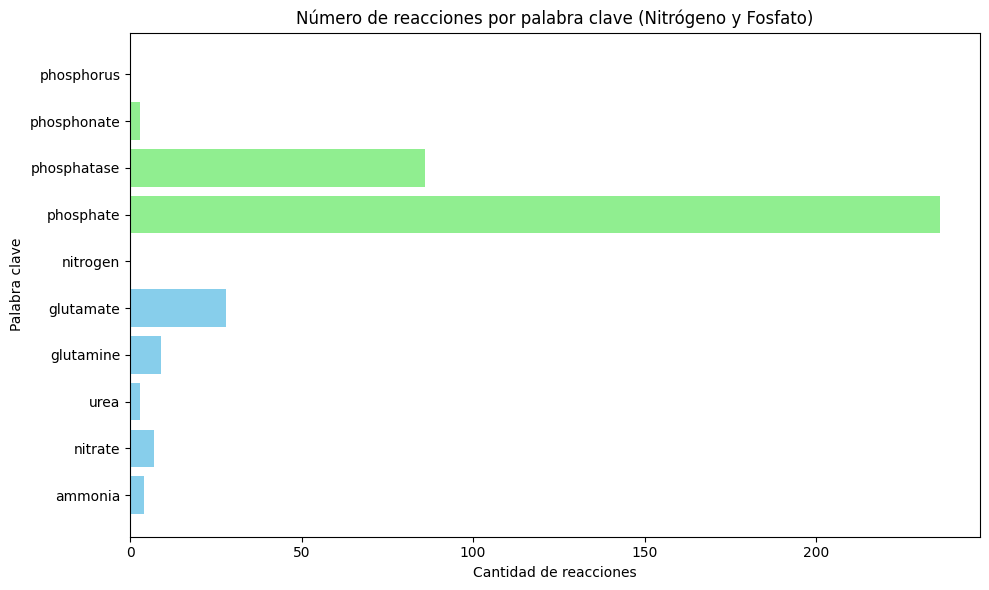

In [41]:
import matplotlib.pyplot as plt

keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
conteo_nitrogeno = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_nitrogeno}

keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

conteo_total = {**conteo_nitrogeno, **conteo_fosfato}

palabras_clave = list(conteo_total.keys())
reacciones = list(conteo_total.values())

colores = ['skyblue' if kw in keywords_nitrogeno else 'lightgreen' for kw in palabras_clave]

plt.figure(figsize=(10, 6))
plt.barh(palabras_clave, reacciones, color=colores)
plt.title("Número de reacciones por palabra clave (Nitrógeno y Fosfato)")
plt.xlabel("Cantidad de reacciones")
plt.ylabel("Palabra clave")
plt.tight_layout()
plt.show()

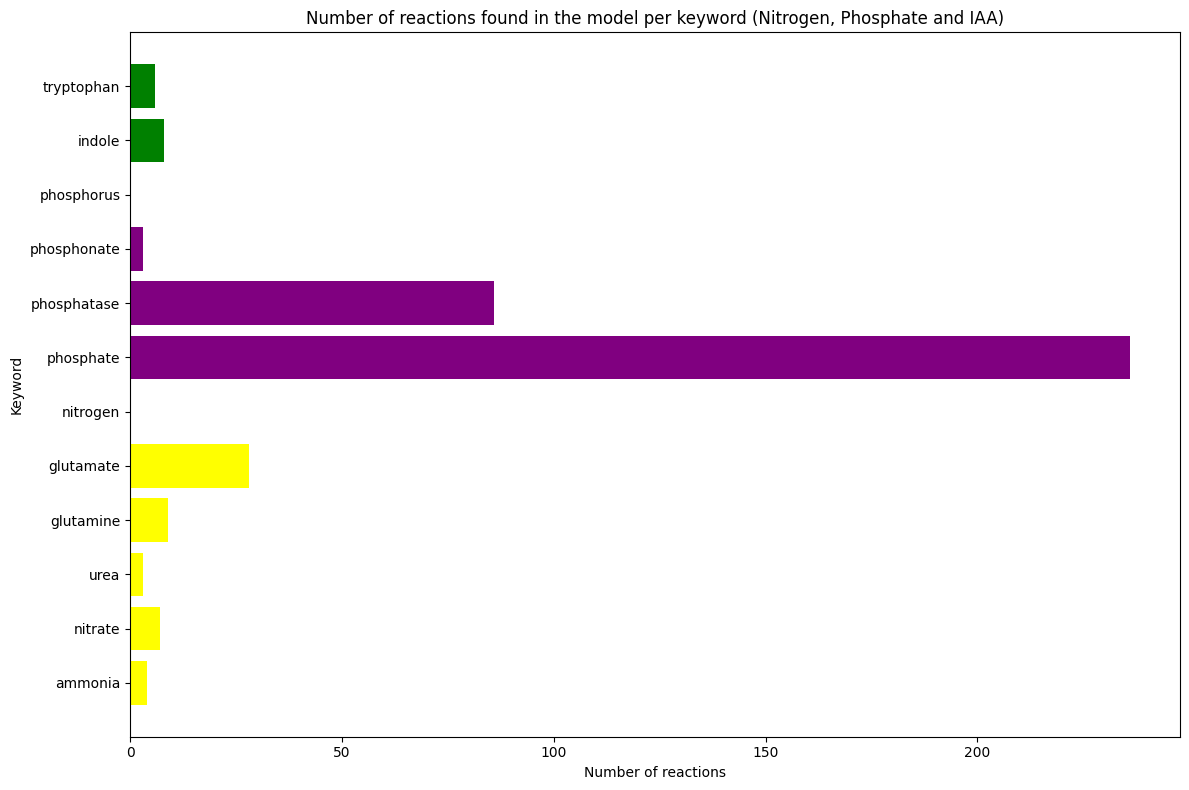

<Figure size 640x480 with 0 Axes>

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
conteo_nitrogeno = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_nitrogeno}

keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

keywords_iaa = ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']
df_iaa_keywords = []
for keyword in keywords_iaa:
    for rxn in buscar_reacciones(model, keyword):
        df_iaa_keywords.append((rxn[0], rxn[1], keyword))
df_iaa_full = pd.DataFrame(df_iaa_keywords, columns=["reaction_id", "reaction_name", "keyword"])
df_iaa_full.drop_duplicates(subset=["reaction_id"], inplace=True)
conteo_iaa = df_iaa_full['keyword'].value_counts().to_dict()

conteo_total = {**conteo_nitrogeno, **conteo_fosfato, **conteo_iaa}
palabras_clave = list(conteo_total.keys())
reacciones = list(conteo_total.values())

colores = []
for kw in palabras_clave:
    if kw in keywords_nitrogeno:
        colores.append('yellow')
    elif kw in keywords_fosfato:
        colores.append('purple')
    else:
        colores.append('green')  # IAA

plt.figure(figsize=(12, 8))
plt.barh(palabras_clave, reacciones, color=colores)
plt.title("Number of reactions found in the model per keyword (Nitrogen, Phosphate and IAA)")
plt.xlabel("Number of reactions")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()

plt.savefig("reacciones_keywords.pdf", format='pdf')  # <- Aquí guardas el gráfico como PDF

plt.show()

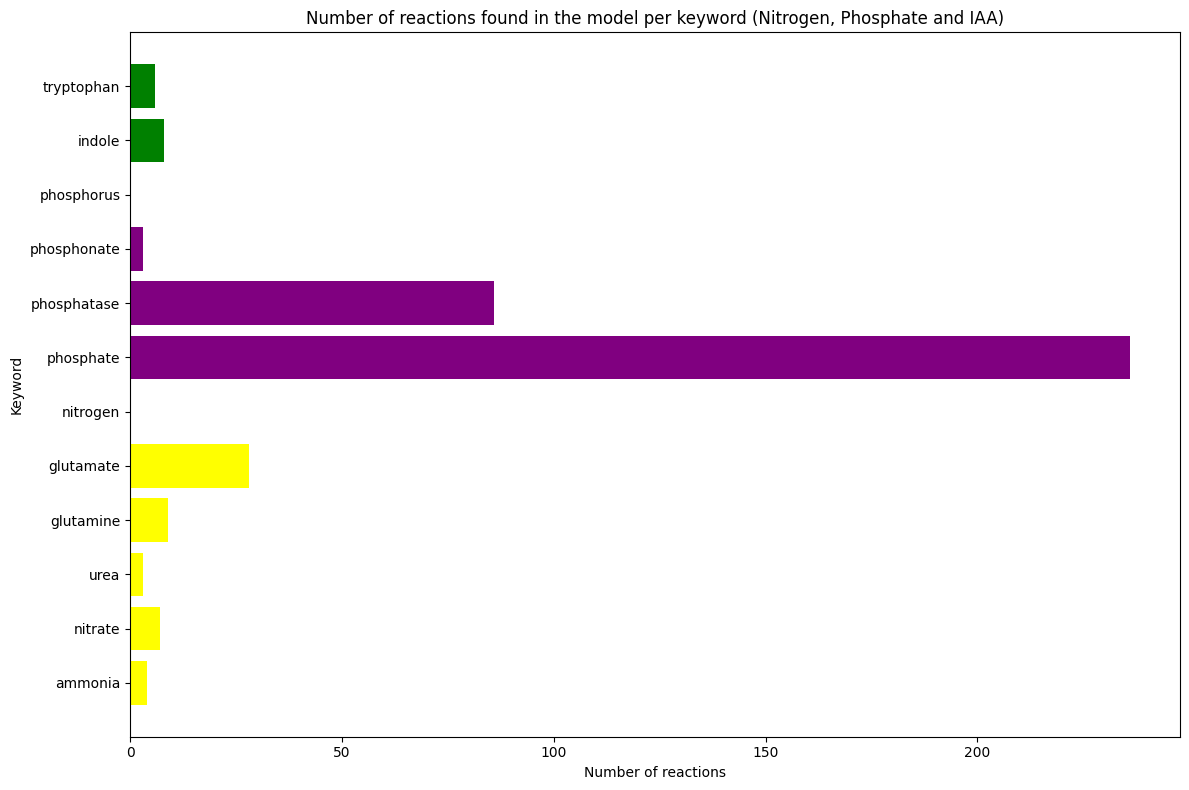

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
conteo_nitrogeno = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_nitrogeno}

keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

keywords_iaa = ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']
df_iaa_keywords = []
for keyword in keywords_iaa:
    for rxn in buscar_reacciones(model, keyword):
        df_iaa_keywords.append((rxn[0], rxn[1], keyword))
df_iaa_full = pd.DataFrame(df_iaa_keywords, columns=["reaction_id", "reaction_name", "keyword"])
df_iaa_full.drop_duplicates(subset=["reaction_id"], inplace=True)
conteo_iaa = df_iaa_full['keyword'].value_counts().to_dict()

conteo_total = {**conteo_nitrogeno, **conteo_fosfato, **conteo_iaa}
palabras_clave = list(conteo_total.keys())
reacciones = list(conteo_total.values())

colores = []
for kw in palabras_clave:
    if kw in keywords_nitrogeno:
        colores.append('yellow')
    elif kw in keywords_fosfato:
        colores.append('purple')
    else:
        colores.append('green')  # IAA

plt.figure(figsize=(12, 8))
plt.barh(palabras_clave, reacciones, color=colores)
plt.title("Number of reactions found in the model per keyword (Nitrogen, Phosphate and IAA)")
plt.xlabel("Number of reactions")
plt.ylabel("Keyword")
plt.tight_layout()

# === Guardar en PDF ===
plt.savefig("reacciones_keywords_finish.pdf", format='pdf')  # <- Aquí guardas el gráfico como PDF

plt.show()

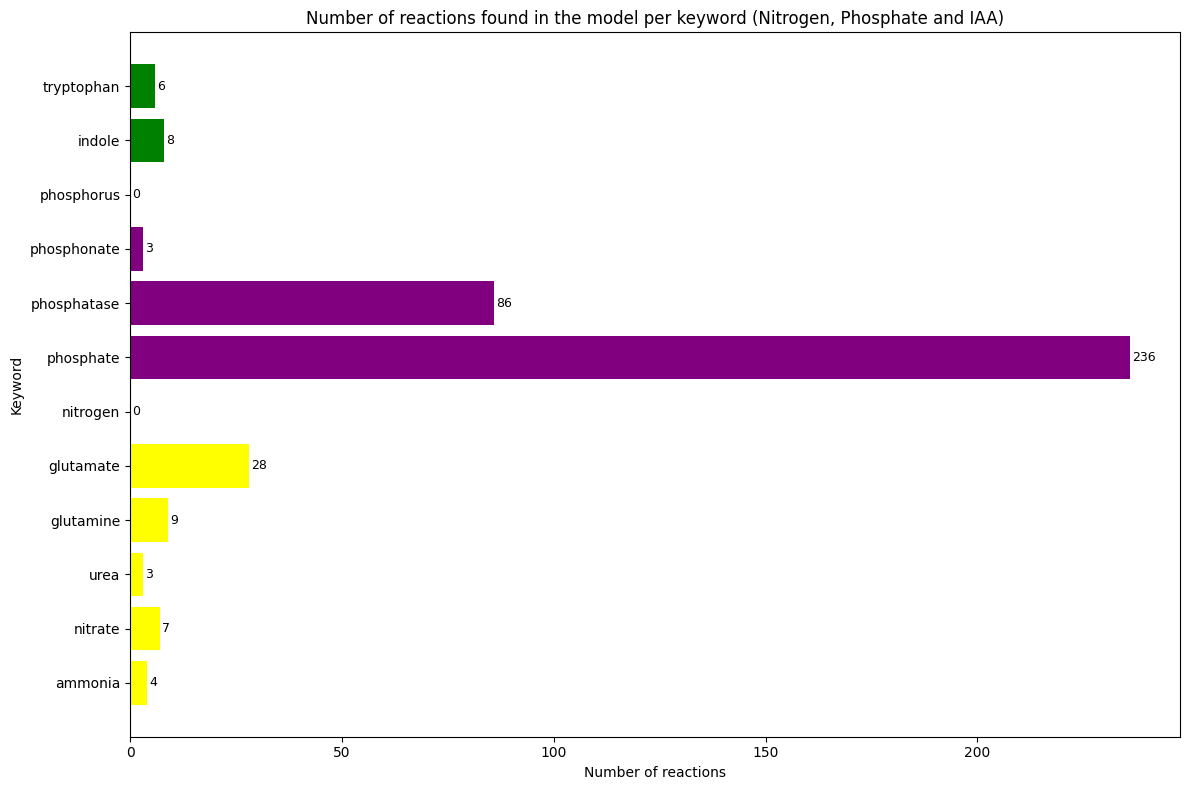

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

#---- Reacciones de Nitrógeno ----
keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
conteo_nitrogeno = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_nitrogeno}

#---- Reacciones de Fosfato ----
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

#---- Reacciones de IAA ----
keywords_iaa = ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']
df_iaa_keywords = []
for keyword in keywords_iaa:
    for rxn in buscar_reacciones(model, keyword):
        df_iaa_keywords.append((rxn[0], rxn[1], keyword))
df_iaa_full = pd.DataFrame(df_iaa_keywords, columns=["reaction_id", "reaction_name", "keyword"])
df_iaa_full.drop_duplicates(subset=["reaction_id"], inplace=True)
conteo_iaa = df_iaa_full['keyword'].value_counts().to_dict()

# ---- Unir todos los datos ----
conteo_total = {**conteo_nitrogeno, **conteo_fosfato, **conteo_iaa}
palabras_clave = list(conteo_total.keys())
reacciones = list(conteo_total.values())

# ---------- colors ---------
colores = []
for kw in palabras_clave:
    if kw in keywords_nitrogeno:
        colores.append('yellow') # NITROGEN
    elif kw in keywords_fosfato:
        colores.append('purple') # FOSFATO
    else:
        colores.append('green')  # IAA

plt.figure(figsize=(12, 8))
bars = plt.barh(palabras_clave, reacciones, color=colores)
plt.title("Number of reactions found in the model per keyword (Nitrogen, Phosphate and IAA)")
plt.xlabel("Number of reactions")
plt.ylabel("Keyword")
plt.tight_layout()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2,
             str(int(width)),
             va='center', ha='left', fontsize=9)

plt.savefig("reacciones_keywords_finish_01.pdf", format='pdf')

plt.show()

In [49]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

model = load_model("iJO1366")

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']

reacciones_nitrogeno = []
for kw in keywords_nitrogeno:
    reacciones_nitrogeno += buscar_reacciones(model, kw)

reacciones_fosfato = []
for kw in keywords_fosfato:
    reacciones_fosfato += buscar_reacciones(model, kw)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))
reacciones_fosfato = list(set(reacciones_fosfato))

fluxes_combinados = {rxn_id: 1.0 for rxn_id, _ in reacciones_nitrogeno}
fluxes_combinados.update({rxn_id: 2.0 for rxn_id, _ in reacciones_fosfato})

df_total = pd.DataFrame(
    reacciones_nitrogeno + reacciones_fosfato, 
    columns=["reaction_id", "reaction_name"]
)
df_total.drop_duplicates(subset=["reaction_id"], inplace=True)
df_total.to_csv("reacciones_nitrogeno_fosfato.csv", index=False)

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_combinados
builder.save_html("mapa_nitrogeno_fosfato.html")

print("Mapa generado como 'mapa_nitrogeno_fosfato.html")
print("Tabla exportada como 'reacciones_nitrogeno_fosfato.csv")

✅ Mapa generado como 'mapa_nitrogeno_fosfato.html'
✅ Tabla exportada como 'reacciones_nitrogeno_fosfato.csv'


In [58]:
from escher import Builder
from cobra.io import load_model
import pandas as pd

model = load_model("iJO1366")  # Usa tu propio modelo si no usas iJO1366

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]

keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']

reacciones_nitrogeno = []
for kw in keywords_nitrogeno:
    reacciones_nitrogeno += buscar_reacciones(model, kw)

reacciones_fosfato = []
for kw in keywords_fosfato:
    reacciones_fosfato += buscar_reacciones(model, kw)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))
reacciones_fosfato = list(set(reacciones_fosfato))

fluxes_combinados = {rxn_id: 1.0 for rxn_id, _ in reacciones_nitrogeno}
fluxes_combinados.update({rxn_id: 2.0 for rxn_id, _ in reacciones_fosfato})

df_total = pd.DataFrame(
    reacciones_nitrogeno + reacciones_fosfato, 
    columns=["reaction_id", "reaction_name"]
)
df_total.drop_duplicates(subset=["reaction_id"], inplace=True)
df_total.to_csv("reacciones_nitrogeno_fosfato.csv", index=False)

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_combinados
builder.save_html("mapa_nitrogeno_fosfato.html")

print("Mapa generado como 'mapa_nitrogeno_fosfato01.html")
print("Tabla exportada como 'reacciones_nitrogeno_fosfato.csv")

Mapa generado como 'mapa_nitrogeno_fosfato01.html
Tabla exportada como 'reacciones_nitrogeno_fosfato.csv


In [57]:
from escher import Builder
from cobra.io import load_model
import pandas as pd


model = load_model("iJO1366")  # Usa tu propio modelo si no usas iJO1366

def buscar_reacciones(model, keyword):
    return [(rxn.id, rxn.name) for rxn in model.reactions
            if keyword.lower() in rxn.name.lower() or keyword.lower() in rxn.id.lower()]


keywords_nitrogeno = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']


reacciones_nitrogeno = []
for kw in keywords_nitrogeno:
    reacciones_nitrogeno += buscar_reacciones(model, kw)

reacciones_fosfato = []
for kw in keywords_fosfato:
    reacciones_fosfato += buscar_reacciones(model, kw)

reacciones_nitrogeno = list(set(reacciones_nitrogeno))
reacciones_fosfato = list(set(reacciones_fosfato))

fluxes_combinados = {rxn_id: 1.0 for rxn_id, _ in reacciones_nitrogeno}
fluxes_combinados.update({rxn_id: 2.0 for rxn_id, _ in reacciones_fosfato})

df_total = pd.DataFrame(
    reacciones_nitrogeno + reacciones_fosfato, 
    columns=["reaction_id", "reaction_name"]
)
df_total.drop_duplicates(subset=["reaction_id"], inplace=True)
df_total.to_csv("reacciones_nitrogeno_fosfato.csv", index=False)

builder = Builder(
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
    model_name='iJO1366'
)

builder.reaction_data = fluxes_combinados
builder.save_html("mapa_nitrogeno_fosfato.html")

print("Mapa generado como 'mapa_nitrogeno_fosfato01.html")
print("Tabla exportada como 'reacciones_nitrogeno_fosfato.csv")

Mapa generado como 'mapa_nitrogeno_fosfato01.html
Tabla exportada como 'reacciones_nitrogeno_fosfato.csv
